In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns

from datasets import  load_dataset

In [3]:
emotion_dataset= load_dataset("dair-ai/emotion")

In [4]:
train_text = emotion_dataset['train']['text']

In [5]:
train_label = emotion_dataset['train']['label']

In [6]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [19]:
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [11]:
names = emotion_dataset['train'].features['label'].names


In [12]:
names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [14]:
# Preview first 10 labels instead of printing all 16,000
for i in train_label[:10]:
    print(names[i])

In [17]:
# Preview first 10 labels instead of printing all 16,000
for i in train_label[:10]:
    print(names[i])

In [18]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [20]:
df_test = pd.DataFrame({
    'text' : test_text,
    "label": [names[i] for i in test_label]

})

In [21]:
df_test

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness
...,...,...
1995,i just keep feeling like someone is being unki...,anger
1996,im feeling a little cranky negative after this...,anger
1997,i feel that i am useful to my people and that ...,joy
1998,im feeling more comfortable with derby i feel ...,joy


<Axes: xlabel='label', ylabel='count'>

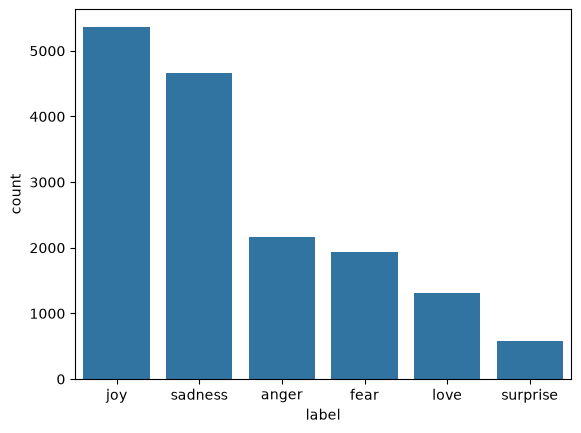

In [26]:
sns.countplot(x ='label',data=df_train, order =df_train['label'].value_counts().index)

## 1. Dataset Overview & Quality Checks
Checking dimensions, missing values, duplicates, and split consistency.

In [ ]:
# Check dimensions and data integrity
print(f"Train samples: {len(df_train)}")
print(f"Test samples:  {len(df_test)}")
print(f"Missing values (Train): {df_train.isnull().sum().to_dict()}")
print(f"Duplicate texts (Train): {df_train['text'].duplicated().sum()}")

# Detailed label counts & percentages in Train
train_counts = df_train['label'].value_counts()
train_pcts = df_train['label'].value_counts(normalize=True) * 100
pd.DataFrame({'Count': train_counts, 'Percentage (%)': train_pcts.round(2)})

## 2. Emotion Label Distribution & Class Imbalance Analysis
Visualizing class distribution across the 6 emotion categories.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Subplot 1: Bar Chart with Count Annotations
plt.subplot(1, 2, 1)
order = df_train['label'].value_counts().index
palette = sns.color_palette('viridis', len(order))
ax = sns.countplot(data=df_train, x='label', order=order, hue='label', legend=False, palette=palette)
plt.title('Emotion Frequency (Training Set)', fontsize=13, fontweight='bold')
plt.xlabel('Emotion', fontsize=11)
plt.ylabel('Count', fontsize=11)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='baseline', fontsize=10, xytext=(0, 5), textcoords='offset points')

# Subplot 2: Pie Chart
plt.subplot(1, 2, 2)
counts = df_train['label'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=palette, startangle=140,
        explode=[0.05 if i < 2 else 0 for i in range(len(counts))], textprops={'fontsize': 11})
plt.title('Class Proportions (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Text Length & Sequence Length Analysis
Analyzing sentence word counts and character counts to determine the optimal transformer `max_length`.

In [ ]:
# Add character and word count features
df_train['char_count'] = df_train['text'].apply(len)
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

print("--- Word Count Summary (Percentiles) ---")
print(df_train['word_count'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

plt.figure(figsize=(15, 5))

# Subplot 1: Overall word count distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df_train, x='word_count', kde=True, bins=35, color='#3498db')
plt.axvline(df_train['word_count'].median(), color='red', linestyle='--', label=f'Median: {df_train["word_count"].median():.0f}')
plt.axvline(df_train['word_count'].quantile(0.95), color='orange', linestyle='--', label=f'95th %ile: {df_train["word_count"].quantile(0.95):.0f}')
plt.axvline(df_train['word_count'].quantile(0.99), color='purple', linestyle='--', label=f'99th %ile: {df_train["word_count"].quantile(0.99):.0f}')
plt.title('Word Count Distribution (All Samples)', fontsize=13, fontweight='bold')
plt.xlabel('Words per Sentence', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.legend()

# Subplot 2: Word counts by emotion
plt.subplot(1, 2, 2)
sns.boxplot(data=df_train, x='label', y='word_count', order=order, hue='label', legend=False, palette=palette)
plt.title('Word Count by Emotion', fontsize=13, fontweight='bold')
plt.xlabel('Emotion', fontsize=11)
plt.ylabel('Word Count', fontsize=11)

plt.tight_layout()
plt.show()

## 4. Top Discriminative Keywords per Emotion (TF-IDF)
Extracting the most distinctive keywords and phrases for each emotion.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Note: ~98.7% of samples contain 'feel' or 'feeling'. Filtering conversational framing words:
custom_stopwords = list(ENGLISH_STOP_WORDS) + ['feel', 'feeling', 'im', 'like', 'just', 'really', 've', 'don', 'didn', 'time', 'little', 'bit']

tfidf = TfidfVectorizer(stop_words=custom_stopwords, max_features=4000, ngram_range=(1, 2))
X = tfidf.fit_transform(df_train['text'])
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, emo in enumerate(names):
    mask = (df_train['label'] == emo).values
    mean_tfidf = X[mask].mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[-8:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_scores = mean_tfidf[top_indices]
    
    sns.barplot(x=top_scores, y=top_words, ax=axes[idx], color='#2980b9')
    axes[idx].set_title(f'Top Keywords: {emo.upper()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Mean TF-IDF Score', fontsize=9)
    axes[idx].tick_params(labelsize=10)

plt.tight_layout()
plt.show()

## 5. Key EDA Takeaways & Modeling Guidelines
1. **Class Imbalance**:
   - `joy` (33.5%) and `sadness` (29.2%) account for ~62.7% of all data.
   - `surprise` (3.6%, 572 samples) and `love` (8.1%) are significantly underrepresented.
   - **Recommendation**: Use class-weighted loss (e.g. `torch.nn.CrossEntropyLoss(weight=...)`) or evaluate with **Macro-F1** rather than pure accuracy.
2. **Tokenizer Max Sequence Length**:
   - 95% of texts have <= 41 words; 99% have <= 52 words (maximum is 66 words).
   - **Recommendation**: Set `max_length = 64` or `80` when tokenizing with BERT / RoBERTa / DistilBERT. Using the standard 512 is wasteful and ~5x slower.
3. **Conversational Framing**:
   - 98.7% of tweets contain "feel" or "feeling" ("i feel like...", "feeling really...").
   - Pre-trained transformer models handle this contextual structure naturally, whereas bag-of-words / TF-IDF models benefit from filtering framing stopwords.